In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

/Users/lequipier/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
train_data = pd.read_csv('training.csv')
test_data = pd.read_csv('test.csv')

In [3]:
train_data.head()

,buying,maint,doors,persons,lug_boot,safety,evaluation
0,low,vhigh,5more,more,small,low,unacc
1,high,high,2,2,big,med,unacc
2,low,vhigh,3,2,med,med,unacc
3,vhigh,low,5more,2,big,med,unacc
4,vhigh,vhigh,4,2,big,med,unacc


In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   buying      1330 non-null   object
 1   maint       1330 non-null   object
 2   doors       1330 non-null   object
 3   persons     1330 non-null   object
 4   lug_boot    1330 non-null   object
 5   safety      1330 non-null   object
 6   evaluation  1330 non-null   object
dtypes: object(7)
memory usage: 72.9+ KB


In [5]:
for i in train_data.columns:
    print(train_data[i].unique(),"\t",train_data[i].nunique())

['low' 'high' 'vhigh' 'med'] 	 4
['vhigh' 'high' 'low' 'med'] 	 4
['5more' '2' '3' '4'] 	 4
['more' '2' '4'] 	 3
['small' 'big' 'med'] 	 3
['low' 'med' 'high'] 	 3
['unacc' 'acc' 'good'] 	 3


In [6]:
for i in train_data.columns:
    print(train_data[i].value_counts())
    print()

high     350
vhigh    340
low      320
med      320
Name: buying, dtype: int64

high     342
vhigh    341
low      328
med      319
Name: maint, dtype: int64

3        346
2        338
4        325
5more    321
Name: doors, dtype: int64

2       453
more    441
4       436
Name: persons, dtype: int64

med      456
small    450
big      424
Name: lug_boot, dtype: int64

low     463
med     458
high    409
Name: safety, dtype: int64

unacc    968
acc      307
good      55
Name: evaluation, dtype: int64



/Users/lequipier/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='evaluation', ylabel='count'>

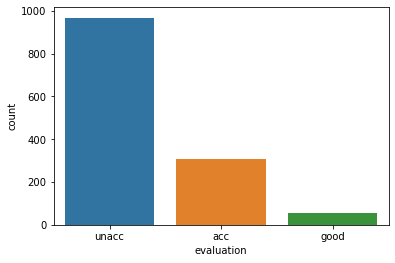

In [7]:
sns.countplot(train_data['evaluation'])

/Users/lequipier/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/Users/lequipier/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/Users/lequipier/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


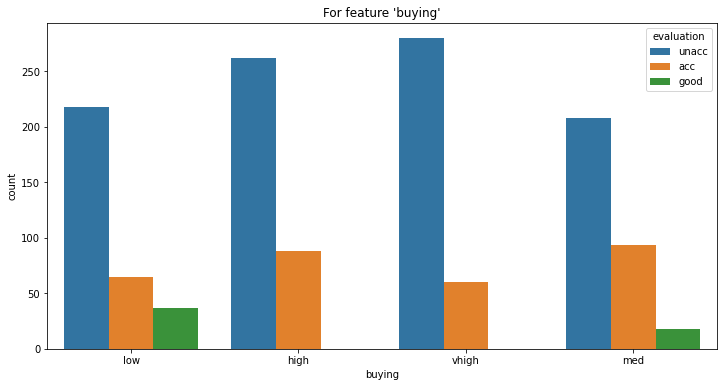

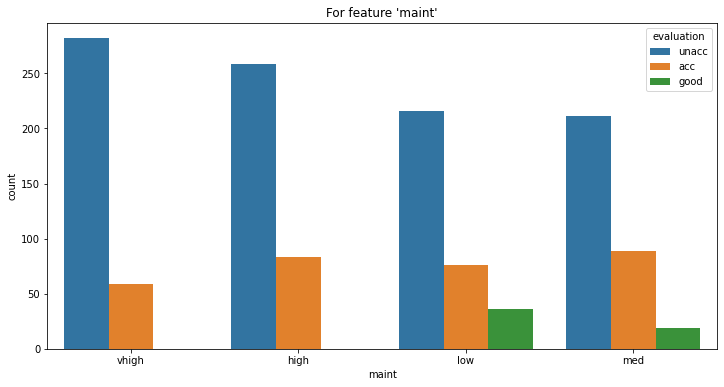

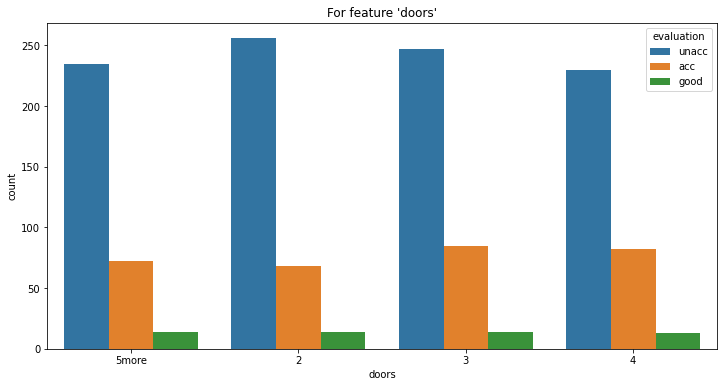

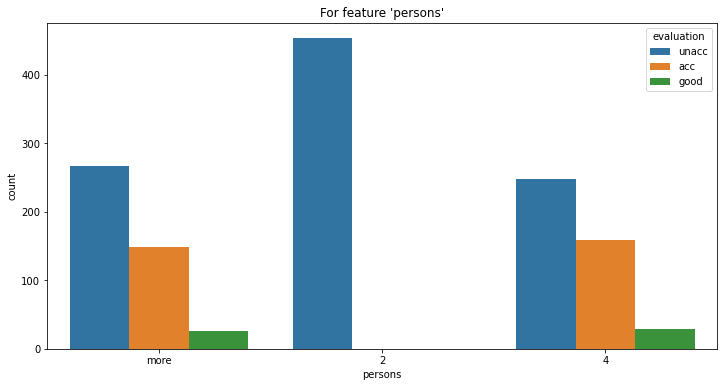

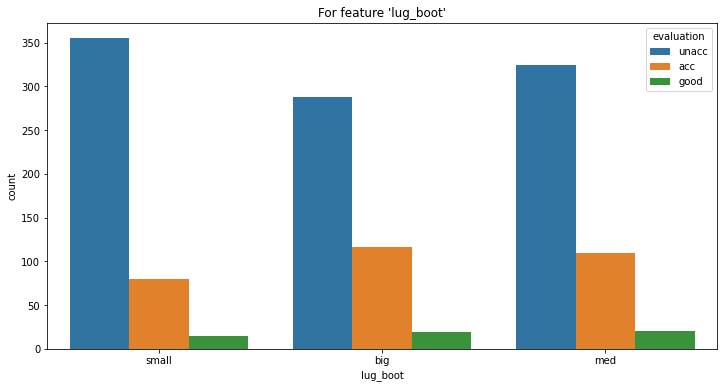

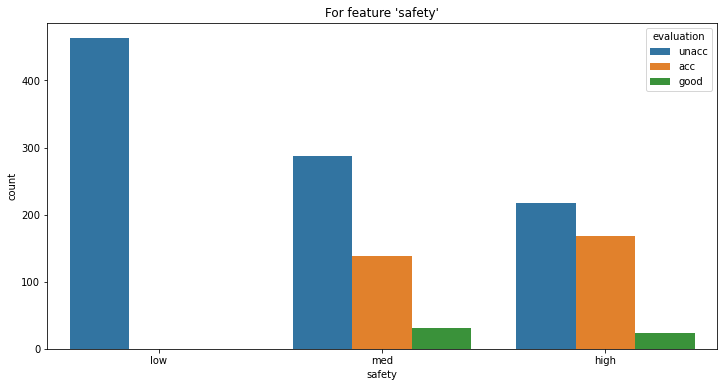

In [8]:
for i in train_data.columns[:-1]:
    plt.figure(figsize=(12,6))
    plt.title("For feature '%s'"%i)
    sns.countplot(train_data[i],hue=train_data['evaluation'])

In [9]:
le=LabelEncoder()

for i in train_data.columns:
    train_data[i]=le.fit_transform(train_data[i])
train_data.head()

train_data.head()

,buying,maint,doors,persons,lug_boot,safety,evaluation
0,1,3,3,2,2,1,2
1,0,0,0,0,0,2,2
2,1,3,1,0,1,2,2
3,3,1,3,0,0,2,2
4,3,3,2,0,0,2,2


In [10]:
for i in test_data.columns:
    test_data[i]=le.fit_transform(test_data[i])

test_data.head()

,buying,maint,doors,persons,lug_boot,safety
0,1,2,2,0,0,1
1,3,2,0,0,1,0
2,3,0,2,1,0,0
3,0,3,2,0,2,2
4,3,0,3,0,2,0


<AxesSubplot:>

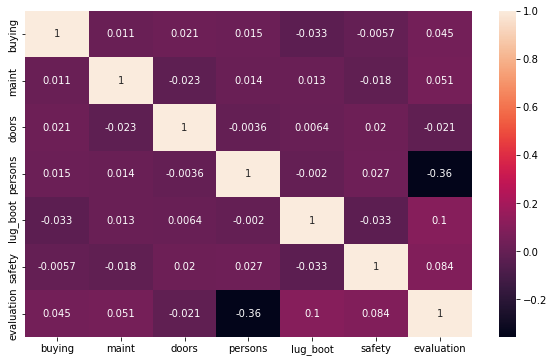

In [11]:
fig=plt.figure(figsize=(10,6))
sns.heatmap(train_data.corr(),annot=True)

In [12]:
X_train=train_data[train_data.columns[:-1]]
y_train=train_data['evaluation']

X_test=test_data[test_data.columns]
y_test=test_data['safety']

In [13]:
X_train.head(2)

,buying,maint,doors,persons,lug_boot,safety
0,1,3,3,2,2,1
1,0,0,0,0,0,2


# Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, learning_curve

In [15]:
logreg=LogisticRegression(solver='newton-cg',multi_class='multinomial')

In [16]:
logreg.fit(X_train,y_train)

LogisticRegression(multi_class='multinomial', solver='newton-cg')

In [17]:
pred=logreg.predict(X_test)

In [18]:
logreg.score(X_test,y_test)

0.3933933933933934

/Users/lequipier/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/Users/lequipier/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/Users/lequipier/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/Users/lequipier/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.

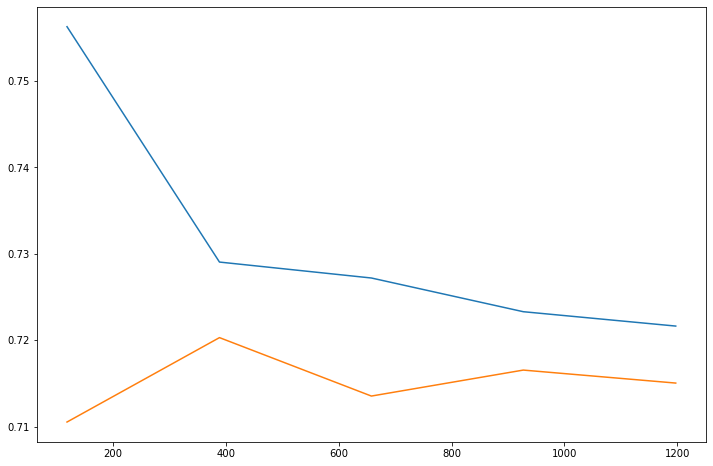

In [19]:
lc=learning_curve(logreg,X_train,y_train,cv=10,n_jobs=-1)
size=lc[0]
train_score=[lc[1][i].mean() for i in range (0,5)]
test_score=[lc[2][i].mean() for i in range (0,5)]
fig=plt.figure(figsize=(12,8))
plt.plot(size,train_score)
plt.plot(size,test_score)

In [20]:
from sklearn.model_selection import learning_curve,cross_val_score,validation_curve
param_range=[0.0001,0.001,0.1,1]
curve=validation_curve(logreg,X_train,y_train,cv=5,param_name='C',
    param_range=param_range,n_jobs=-1,)

In [21]:
curve

(array([[0.72744361, 0.72744361, 0.72744361, 0.72838346, 0.72838346],
        [0.72744361, 0.72744361, 0.72744361, 0.72838346, 0.72838346],
        [0.72462406, 0.72180451, 0.72462406, 0.72838346, 0.72274436],
        [0.71710526, 0.71898496, 0.71992481, 0.72650376, 0.72086466]]),
 array([[0.72932331, 0.72932331, 0.72932331, 0.72556391, 0.72556391],
        [0.72932331, 0.72932331, 0.72932331, 0.72556391, 0.72556391],
        [0.72180451, 0.7443609 , 0.70676692, 0.73308271, 0.69924812],
        [0.72180451, 0.72932331, 0.70300752, 0.72932331, 0.69548872]]))

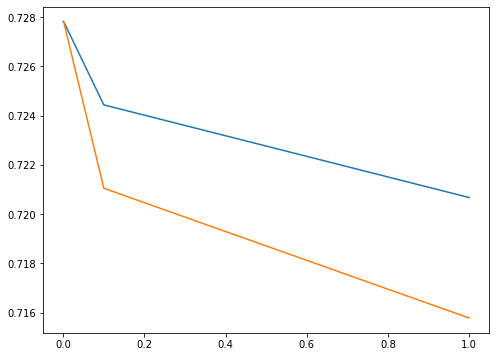

In [22]:
n=len(param_range)
train_score=[curve[0][i].mean() for i in range (0,n)]
test_score=[curve[1][i].mean() for i in range (0,n)]
fig=plt.figure(figsize=(8,6))
plt.plot(param_range,train_score)
plt.plot(param_range,test_score)
plt.xticks=param_range

In [23]:

param_grid={'C':[0.01,0.1,1,10],
           'solver':['newton-cg', 'lbfgs', 'sag'],
           'multi_class':['multinomial']}
grid=GridSearchCV(estimator=LogisticRegression(n_jobs=-1),param_grid=param_grid,cv=5,n_jobs=-1)

In [24]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(n_jobs=-1), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'multi_class': ['multinomial'],
                         'solver': ['newton-cg', 'lbfgs', 'sag']})

In [25]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 0.01, 'multi_class': 'multinomial', 'solver': 'newton-cg'}
0.7285714285714286
